In [ ]:
## Script sketch

# Import necessary libraries
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define function to extract keypoints
def extract_keypoints(json_file_path):
    # ...

# Define function to calculate measurements
def calculate_measurements(keypoints):
    # ...

# Define function to visualize skeleton
def visualize_skeleton(keypoints):
    # ...

# Define function to process all files in a directory
def process_all_files(directory_path):
    measurements = []
    for file_path in os.listdir(directory_path):
        if file_path.endswith('.json'):
            keypoints = extract_keypoints(os.path.join(directory_path, file_path))
            measurement = calculate_measurements(keypoints)
            session_name = os.path.splitext(file_path)[0]
            measurements.append({"session_name": session_name, **measurement})
    return measurements

# Define function to save measurements to CSV
def save_measurements_to_csv(measurements, output_file):
    df = pd.DataFrame(measurements)
    df.to_csv(output_file, index=False)

# Test with a single file (for development and debugging)
test_file_path = 'path/to/test/file.json'
keypoints = extract_keypoints(test_file_path)
visualize_skeleton(keypoints)

# Process all files and save measurements
directory_path = 'path/to/your/files'
measurements = process_all_files(directory_path)
save_measurements_to_csv(measurements, 'output_measurements.csv')


Read one frame from a Json file

In [2]:
import json

# Path to the JSON file
json_file_path = 'Public_Test_Data/Skeleton_From_Video/SMC-07272023-33_D_Ten_keypoints.json'  # Replace with your file path

# Reading the JSON file
with open(json_file_path, 'r') as file:
    data = json.load(file)

# Find the first frame with non-empty poses
first_non_empty_frame = next((frame for frame in data if frame["poses"]), None)

# Extract keypoints if a non-empty frame is found
if first_non_empty_frame:
    keypoints = first_non_empty_frame.get("poses", [[]])[0]
    print("Keypoints from the first non-empty frame:")
    print(keypoints)
else:
    print("No non-empty poses found in any frame.")


Keypoints from the first non-empty frame:
[[441.7643127441406, 139.2386016845703, 0.843004584312439], [441.7643127441406, 132.1265411376953, 0.7378764152526855], [434.6522521972656, 132.1265411376953, 0.8064654469490051], [406.2039489746094, 132.1265411376953, 0.7549700736999512], [409.7599792480469, 132.1265411376953, 0.8024669885635376], [416.8720397949219, 171.2428741455078, 0.8017778992652893], [395.5358581542969, 167.6868438720703, 0.9160783290863037], [423.9841003417969, 235.2514190673828, 0.6526681184768677], [391.9798278808594, 228.1393585205078, 0.8718388080596924], [427.5401306152344, 281.47979736328125, 0.7735521793365479], [409.7599792480469, 277.92376708984375, 0.8743033409118652], [420.4280700683594, 277.92376708984375, 0.7650929689407349], [402.6479187011719, 277.92376708984375, 0.7998723983764648], [409.7599792480469, 356.15643310546875, 0.8606746792793274], [399.0918884277344, 359.71246337890625, 0.8853315114974976], [413.3160095214844, 427.27703857421875, 0.8895491957

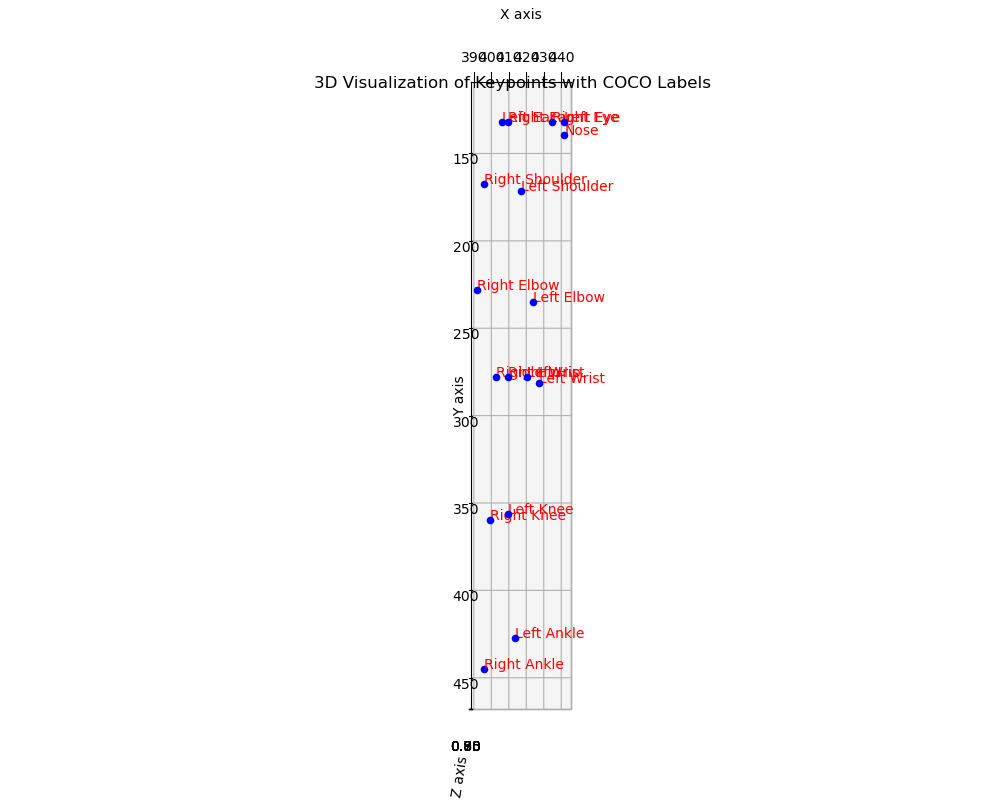

In [4]:
%matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract x, y, z coordinates from keypoints
x = [kp[0] for kp in keypoints]
y = [kp[1] for kp in keypoints]
z = [kp[2] for kp in keypoints]

# COCO keypoint labels
coco_labels = [
    "Nose", "Left Eye", "Right Eye", "Left Ear", "Right Ear",
    "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
    "Left Wrist", "Right Wrist", "Left Hip", "Right Hip",
    "Left Knee", "Right Knee", "Left Ankle", "Right Ankle"
]

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Ensure there are enough keypoints
if len(keypoints) >= len(coco_labels):
    for i, (x, y, z) in enumerate(keypoints):
        ax.scatter(x, y, z, color='blue')  # Plot each keypoint
        ax.text(x, y, z, coco_labels[i], color='red', fontsize=10)  # Label each keypoint

# Setting labels and title
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_aspect('equal')
ax.view_init(azim=0, elev=-90, roll=-90) #rotate to face forward

ax.set_title('3D Visualization of Keypoints with COCO Labels')

plt.show()

